Aperçu du dataset :
        Date   Time                            Location  \
0  9/17/1908  17:18                 Fort Myer, Virginia   
1   9/7/1909    NaN             Juvisy-sur-Orge, France   
2  7/12/1912   6:30           Atlantic City, New Jersey   
3   8/6/1913    NaN  Victoria, British Columbia, Canada   
4   9/9/1913  18:30                  Over the North Sea   

                 Operator Flight #          Route                 AC Type  \
0    Military - U.S. Army      NaN  Demonstration        Wright Flyer III   
1                     NaN      NaN       Air show          Wright Byplane   
2    Military - U.S. Navy      NaN    Test flight               Dirigible   
3                 Private      NaN            NaN        Curtiss seaplane   
4  Military - German Navy      NaN            NaN  Zeppelin L-1 (airship)   

  Registration cn/ln  Aboard  Aboard Passangers  Aboard Crew  Fatalities  \
0          NaN     1     2.0                1.0          1.0         1.0   
1         

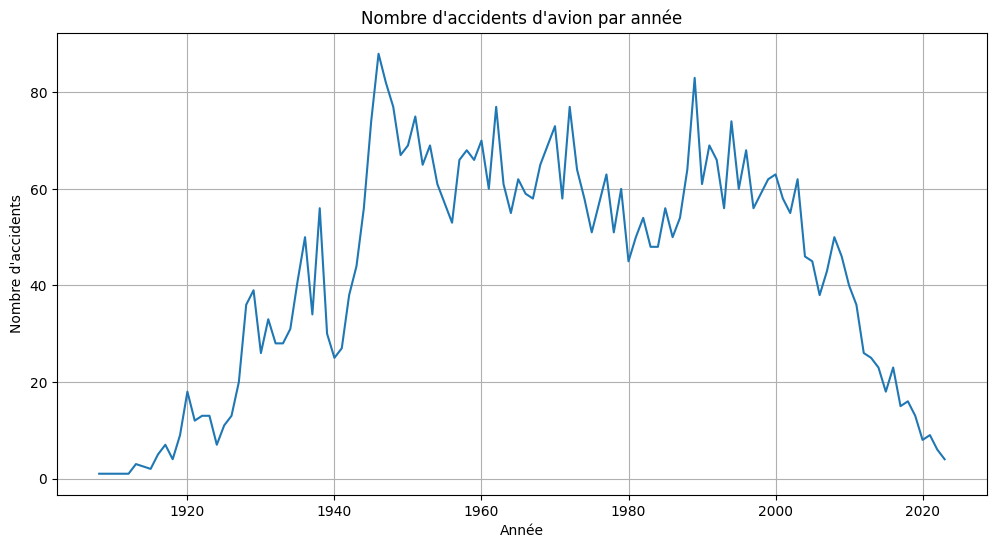

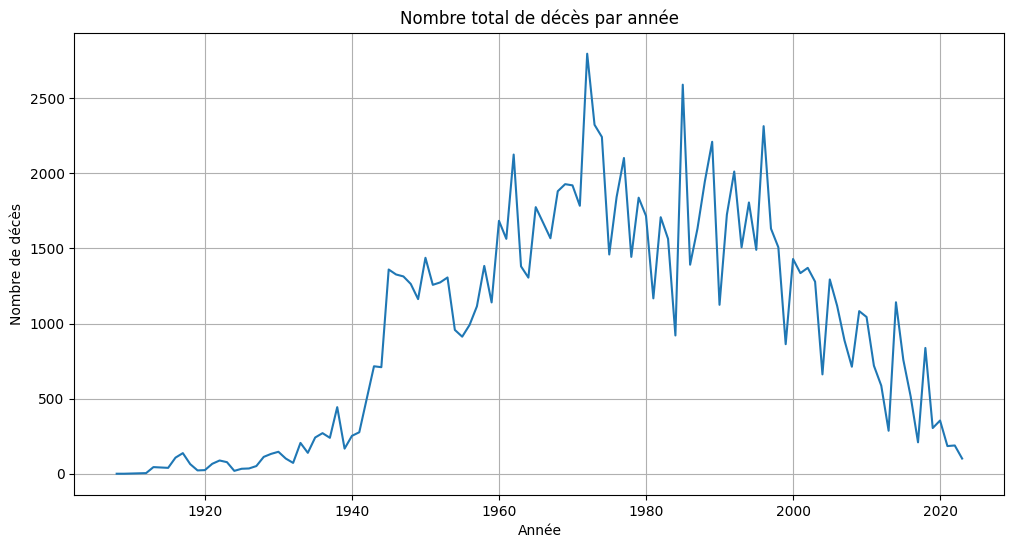


Accidents par décennie :
Decade
1900      2
1910     31
1920    182
1930    357
1940    578
1950    649
1960    636
1970    612
1980    552
1990    631
2000    506
2010    235
2020     27
dtype: int64


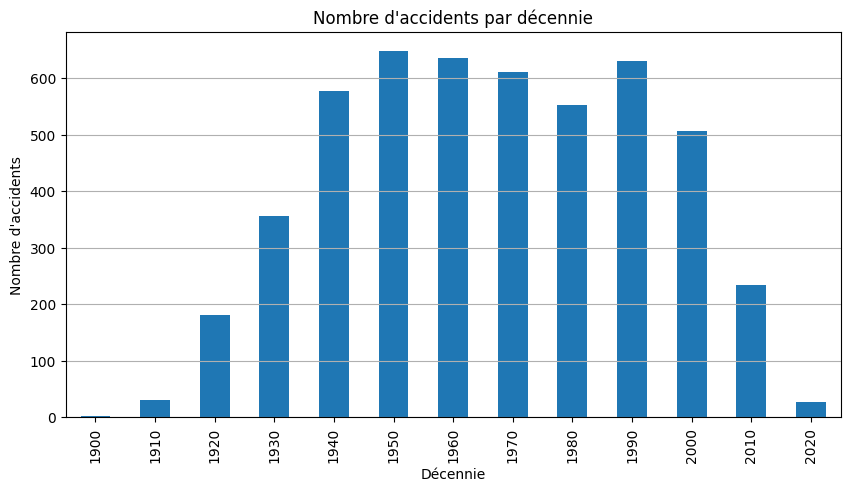


Décès par décennie :
Decade
1900        2.0
1910      424.0
1920      647.0
1930     2033.0
1940     8881.0
1950    11779.0
1960    16884.0
1970    19751.0
1980    16847.0
1990    15984.0
2000    11174.0
2010     6407.0
2020      831.0
Name: Fatalities, dtype: float64


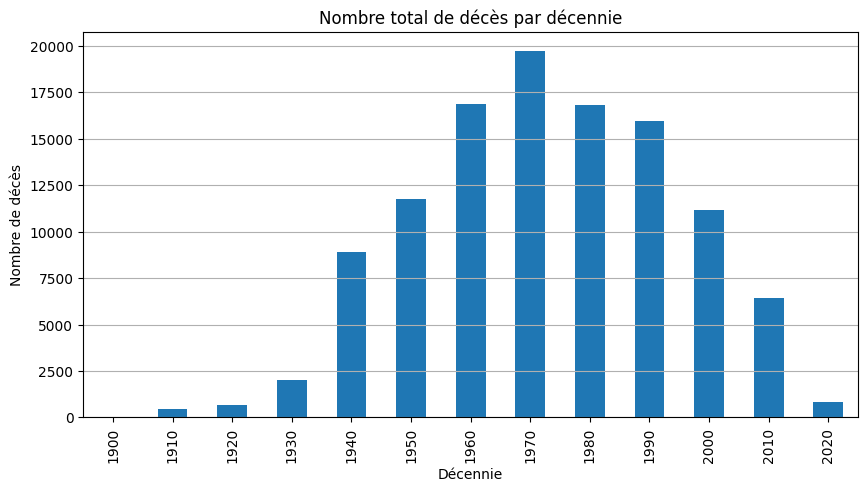


Analyse statistique des décès :
Moyenne des décès : 22.337735094037615
Médiane des décès : 11.0
Écart-type des décès : 35.04157452812883

Statistiques détaillées avec SciPy :
DescribeResult(nobs=np.int64(4998), minmax=(np.float64(0.0), np.float64(583.0)), mean=np.float64(22.337735094037615), variance=np.float64(1228.1576752373953), skewness=np.float64(4.607867742724986), kurtosis=np.float64(36.62827882593468))


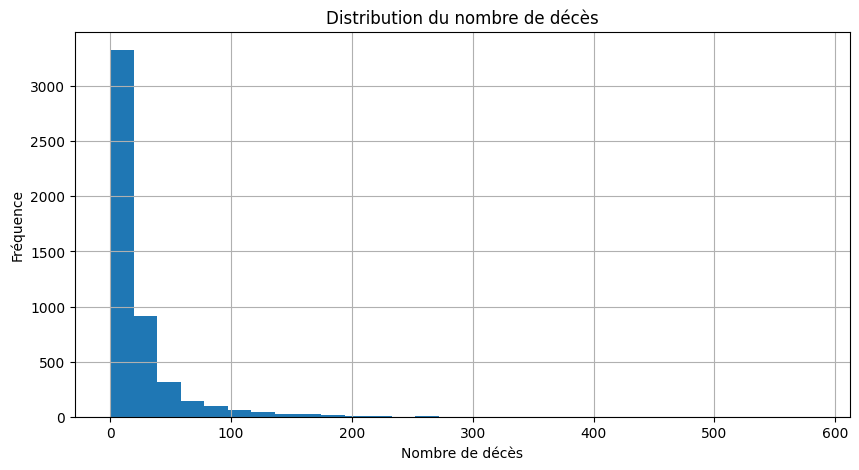

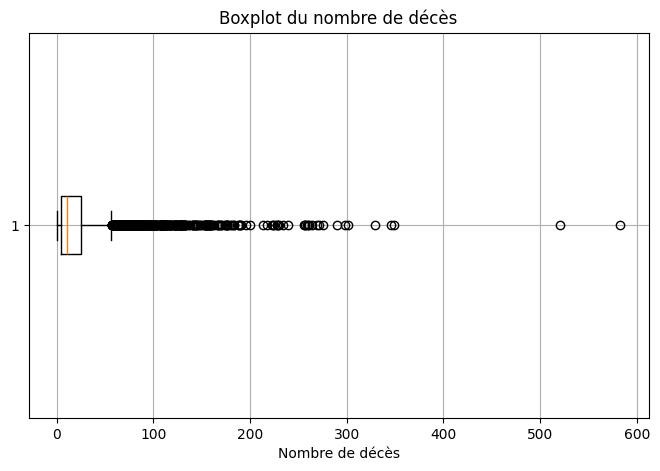


Décennies disponibles :
[np.int32(1900), np.int32(1910), np.int32(1920), np.int32(1930), np.int32(1940), np.int32(1950), np.int32(1960), np.int32(1970), np.int32(1980), np.int32(1990), np.int32(2000), np.int32(2010), np.int32(2020)]

Test t entre les décennies 2010 et 2020 :
Statistique t : -0.40061516514245205
Valeur p : 0.6912666318630512
Conclusion : Il n'existe pas de différence significative entre les deux décennies.

Top 10 des lieux avec le plus d'accidents :
Location
Moscow, Russia            17
Manila, Philippines       15
New York, New York        14
Sao Paulo, Brazil         13
Cairo, Egypt              13
Rio de Janeiro, Brazil    12
Bogota, Colombia          12
Chicago, Illinois         11
Near Moscow, Russia       11
Tehran, Iran              10
Name: count, dtype: int64


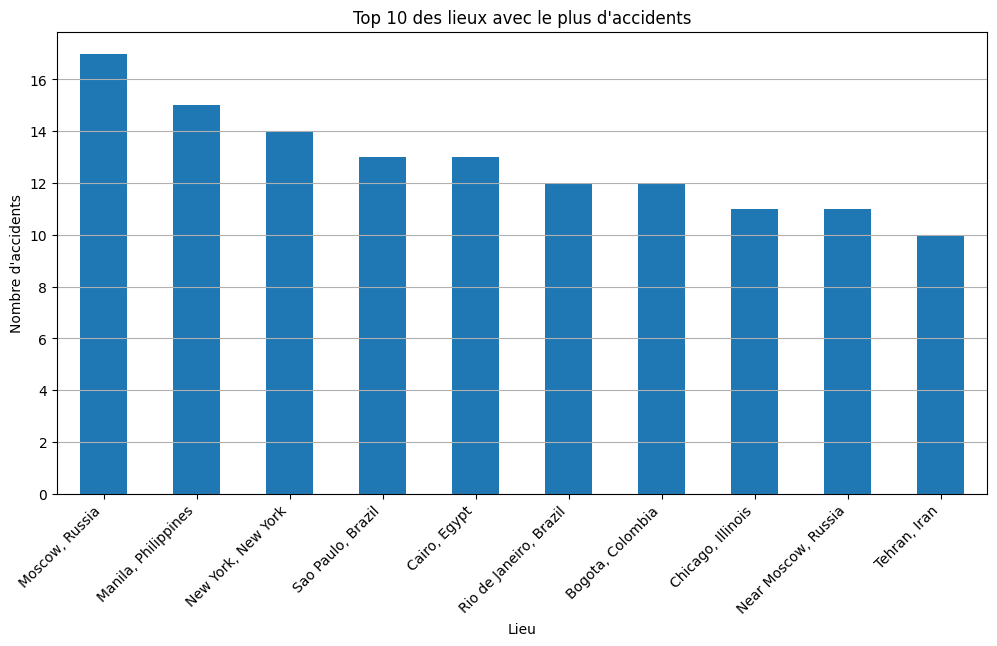


Corrélation entre personnes à bord et décès :
              Aboard  Fatalities
Aboard      1.000000    0.740349
Fatalities  0.740349    1.000000


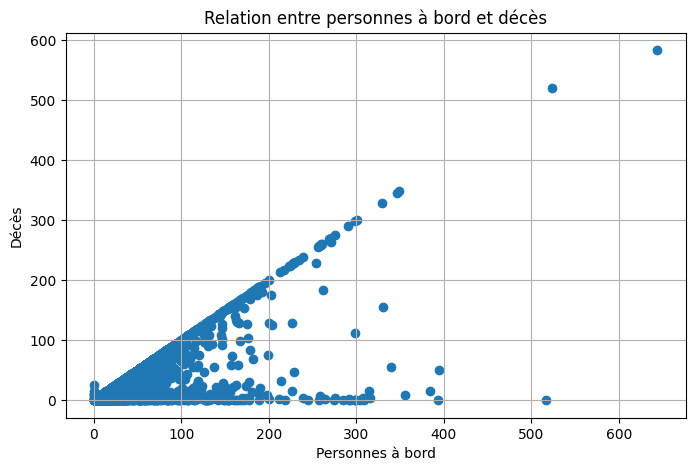


================ RAPPORT FINAL ================

1. Importation et nettoyage
Le dataset a été importé avec Pandas en utilisant l'encodage latin1 afin d'éviter l'erreur UnicodeDecodeError.
Les colonnes ont été nettoyées, les dates ont été converties au format datetime et les colonnes numériques ont été converties au bon format.

2. Analyse exploratoire
Nombre total d'accidents : 4998
Nombre total de décès : 111644.0
Nombre total de personnes à bord : 155356.0

3. Statistiques principales
Moyenne des décès par accident : 22.34
Médiane des décès par accident : 11.0
Écart-type des décès : 35.04

4. Analyse temporelle
Première année observée : 1908
Dernière année observée : 2023

5. Analyse statistique
SciPy a été utilisé pour produire des statistiques descriptives et réaliser un test d'hypothèse entre deux décennies.

6. Conclusion générale
L'analyse montre l'évolution des accidents d'avion et des décès au fil du temps.
Les visualisations permettent d'identifier les périodes les plus marq

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import ttest_ind


file_path = "/content/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Aperçu du dataset :")
print(df.head())

print("\nDimensions du dataset :")
print(df.shape)

print("\nColonnes disponibles :")
print(df.columns)

print("\nInformations générales :")
print(df.info())


df.columns = df.columns.str.strip()

print("\nColonnes après nettoyage :")
print(df.columns)

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


date_column = "Date"
fatality_column = "Fatalities"
aboard_column = "Aboard"
location_column = "Location"

print("\nColonne date utilisée :", date_column)
print("Colonne décès utilisée :", fatality_column)
print("Colonne personnes à bord utilisée :", aboard_column)
print("Colonne lieu utilisée :", location_column)


df[date_column] = pd.to_datetime(df[date_column], errors="coerce")

df["Year"] = df[date_column].dt.year
df["Month"] = df[date_column].dt.month
df["Decade"] = (df["Year"] // 10) * 10

df[fatality_column] = pd.to_numeric(df[fatality_column], errors="coerce")
df[aboard_column] = pd.to_numeric(df[aboard_column], errors="coerce")

df[fatality_column] = df[fatality_column].fillna(0)
df[aboard_column] = df[aboard_column].fillna(0)


df["Survivors"] = df[aboard_column] - df[fatality_column]

df["Survival_Rate"] = np.where(
    df[aboard_column] > 0,
    df["Survivors"] / df[aboard_column],
    np.nan
)

df["Fatality_Rate"] = np.where(
    df[aboard_column] > 0,
    df[fatality_column] / df[aboard_column],
    np.nan
)

print("\nAperçu après nettoyage :")
print(df.head())

nombre_accidents = len(df)
nombre_deces = df[fatality_column].sum()
nombre_personnes_abord = df[aboard_column].sum()

print("\nNombre total d'accidents :", nombre_accidents)
print("Nombre total de décès :", nombre_deces)
print("Nombre total de personnes à bord :", nombre_personnes_abord)

print("\nStatistiques descriptives des décès :")
print(df[fatality_column].describe())

print("\nStatistiques du taux de survie :")
print(df["Survival_Rate"].describe())


accidents_by_year = df.groupby("Year").size()

print("\nNombre d'accidents par année :")
print(accidents_by_year.head())

plt.figure(figsize=(12, 6))
accidents_by_year.plot()
plt.title("Nombre d'accidents d'avion par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")
plt.grid(True)
plt.show()


deaths_by_year = df.groupby("Year")[fatality_column].sum()

plt.figure(figsize=(12, 6))
deaths_by_year.plot()
plt.title("Nombre total de décès par année")
plt.xlabel("Année")
plt.ylabel("Nombre de décès")
plt.grid(True)
plt.show()


accidents_by_decade = df.groupby("Decade").size()

print("\nAccidents par décennie :")
print(accidents_by_decade)

plt.figure(figsize=(10, 5))
accidents_by_decade.plot(kind="bar")
plt.title("Nombre d'accidents par décennie")
plt.xlabel("Décennie")
plt.ylabel("Nombre d'accidents")
plt.grid(axis="y")
plt.show()


deaths_by_decade = df.groupby("Decade")[fatality_column].sum()

print("\nDécès par décennie :")
print(deaths_by_decade)

plt.figure(figsize=(10, 5))
deaths_by_decade.plot(kind="bar")
plt.title("Nombre total de décès par décennie")
plt.xlabel("Décennie")
plt.ylabel("Nombre de décès")
plt.grid(axis="y")
plt.show()


fatalities = df[fatality_column].dropna()

mean_fatalities = np.mean(fatalities)
median_fatalities = np.median(fatalities)
std_fatalities = np.std(fatalities)

print("\nAnalyse statistique des décès :")
print("Moyenne des décès :", mean_fatalities)
print("Médiane des décès :", median_fatalities)
print("Écart-type des décès :", std_fatalities)

print("\nStatistiques détaillées avec SciPy :")
print(stats.describe(fatalities))


plt.figure(figsize=(10, 5))
plt.hist(df[fatality_column].dropna(), bins=30)
plt.title("Distribution du nombre de décès")
plt.xlabel("Nombre de décès")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.boxplot(df[fatality_column].dropna(), vert=False)
plt.title("Boxplot du nombre de décès")
plt.xlabel("Nombre de décès")
plt.grid(True)
plt.show()


available_decades = sorted(df["Decade"].dropna().unique())

print("\nDécennies disponibles :")
print(available_decades)

if len(available_decades) >= 2:
    decade_1 = available_decades[-2]
    decade_2 = available_decades[-1]

    group1 = df[df["Decade"] == decade_1][fatality_column].dropna()
    group2 = df[df["Decade"] == decade_2][fatality_column].dropna()

    t_stat, p_value = ttest_ind(group1, group2, equal_var=False)

    print(f"\nTest t entre les décennies {decade_1} et {decade_2} :")
    print("Statistique t :", t_stat)
    print("Valeur p :", p_value)

    alpha = 0.05

    if p_value < alpha:
        print("Conclusion : Il existe une différence significative entre les deux décennies.")
    else:
        print("Conclusion : Il n'existe pas de différence significative entre les deux décennies.")


top_locations = df[location_column].value_counts().head(10)

print("\nTop 10 des lieux avec le plus d'accidents :")
print(top_locations)

plt.figure(figsize=(12, 6))
top_locations.plot(kind="bar")
plt.title("Top 10 des lieux avec le plus d'accidents")
plt.xlabel("Lieu")
plt.ylabel("Nombre d'accidents")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()


correlation = df[[aboard_column, fatality_column]].corr()

print("\nCorrélation entre personnes à bord et décès :")
print(correlation)

plt.figure(figsize=(8, 5))
plt.scatter(df[aboard_column], df[fatality_column])
plt.title("Relation entre personnes à bord et décès")
plt.xlabel("Personnes à bord")
plt.ylabel("Décès")
plt.grid(True)
plt.show()


print("\n================ RAPPORT FINAL ================")

print("\n1. Importation et nettoyage")
print("Le dataset a été importé avec Pandas en utilisant l'encodage latin1 afin d'éviter l'erreur UnicodeDecodeError.")
print("Les colonnes ont été nettoyées, les dates ont été converties au format datetime et les colonnes numériques ont été converties au bon format.")

print("\n2. Analyse exploratoire")
print("Nombre total d'accidents :", nombre_accidents)
print("Nombre total de décès :", nombre_deces)
print("Nombre total de personnes à bord :", nombre_personnes_abord)

print("\n3. Statistiques principales")
print("Moyenne des décès par accident :", round(mean_fatalities, 2))
print("Médiane des décès par accident :", round(median_fatalities, 2))
print("Écart-type des décès :", round(std_fatalities, 2))

print("\n4. Analyse temporelle")
print("Première année observée :", int(df["Year"].min()))
print("Dernière année observée :", int(df["Year"].max()))

print("\n5. Analyse statistique")
print("SciPy a été utilisé pour produire des statistiques descriptives et réaliser un test d'hypothèse entre deux décennies.")

print("\n6. Conclusion générale")
print("L'analyse montre l'évolution des accidents d'avion et des décès au fil du temps.")
print("Les visualisations permettent d'identifier les périodes les plus marquées par les accidents et les lieux les plus concernés.")
print("Cette étude montre comment Pandas, NumPy, SciPy et Matplotlib peuvent être utilisés pour nettoyer, analyser et visualiser un dataset réel.")